In [4]:
# %%
from pathlib import Path
import pandas as pd, numpy as np
from collections import defaultdict
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import LeaveOneOut
import math, re

# Rutas --------------------------------------------------------------------
DATA_DIR = Path("datos_sliding")   # EscenaX/1.tsv … 4.tsv (1 Hz)

# Escala px↔cm -------------------------------------------------------------
PX_PER_CM = 550/380    # ajusta a tu calibración

# Anclas (IDs en el mismo orden que los archivos 1.tsv‑4.tsv) --------------
ANCHOR_IDS = [f"Raspy{i}" for i in range(1,5)]

# Ground‑truth --------------------------------------------------------------
TRUTH_POINTS = {"A": (100,500), "B": (122,223), "C": (370,490), "D": (283,179)}
GT_SCHEDULES = {
    "config1": [("1:02","1:20","D"),("1:21","1:40","C"),("1:41","1:55","A"),("1:56","2:05","B")],
    "config2": [("2:36","2:56","B"),("2:57","3:06","A"),("3:07","3:27","C"),("3:28","3:36","D")],
    "config3": [("11:55","12:10","C"),("12:11","12:25","D"),("12:26","12:36","B"),("12:37","12:55","A")],
    "config4": [("13:13","13:34","A"),("13:35","13:49","B"),("13:50","14:04","C"),("14:05","14:13","D")],
    "config5": [("14:59","15:15","B"),("15:16","15:35","C"),("15:36","15:50","A"),("15:51","15:59","D")],
    "config6": [("16:20","16:41","D"),("16:42","16:56","B"),("16:57","17:10","C"),("17:11","17:20","A")],
}

# %% [markdown]
# ## 1. Utilidades de lectura y GT

# %%
def read_raspy(path: Path):
    df = pd.read_csv(path, sep="\t", header=None,
                     names=["timestamp","distance","rssi"])
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce").astype("Int64")
    df["rssi"] = pd.to_numeric(df["rssi"], errors="coerce")
    return df.dropna(subset=["timestamp","rssi"])

def build_lut(schedule):
    lut=[]
    for a,b,label in schedule:
        m0,s0=map(int,a.split(':')); m1,s1=map(int,b.split(':'))
        lut.append((m0*60+s0,m1*60+s1,TRUTH_POINTS[label]))
    return lut

def gt_for(sec,lut):
    for t0,t1,pt in lut:
        if t0<=sec<=t1:
            return pt
    return lut[-1][2]

def load_scene(esc_dir: Path):
    frames=[]
    for idx,aid in enumerate(ANCHOR_IDS,1):
        df=read_raspy(esc_dir/f"{idx}.tsv")
        df=df[["timestamp","rssi"]].rename(columns={"rssi":f"rssi_{aid}"})
        frames.append(df)
    wide=frames[0]
    for dfi in frames[1:]:
        wide=wide.merge(dfi,on="timestamp",how="inner")
    return wide

# %% [markdown]
# ## 2. Conjunto global de fingerprints

# %%
rows=[]
for esc in sorted(DATA_DIR.glob("config*")):
    name=esc.name
    df=load_scene(esc)
    if df.empty:
        continue
    lut=build_lut(GT_SCHEDULES[name])
    t0=df["timestamp"].min()
    df[["gt_x","gt_y"]]= (df["timestamp"]-t0).apply(lambda s: pd.Series(gt_for(s,lut)))
    df["esc"] = name
    rows.append(df)

data=pd.concat(rows,ignore_index=True)
print("Fingerprint global:", data.shape)

# %% [markdown]
# ## 3. Training global + MAE

# %%
X = data[[f"rssi_{aid}" for aid in ANCHOR_IDS]].values
Y_px = data[["gt_x","gt_y"]].values
Y_cm = Y_px / PX_PER_CM

scaler = StandardScaler().fit(X)
X_s = scaler.transform(X)
knn = KNeighborsRegressor(n_neighbors=5, weights="distance").fit(X_s, Y_cm)
Y_pred = knn.predict(X_s)
mae_cm = np.mean(np.linalg.norm(Y_pred - Y_cm, axis=1))
print(f"Global train+test MAE ≈ {mae_cm:.2f} cm  ({mae_cm*PX_PER_CM:.2f} px)")

# %% [markdown]
# ## 4. Leave‑One‑Out **intra‑scene** MAE

# %%
scene_mae={}
for esc,grp in data.groupby("esc"):
    X_esc = grp[[f"rssi_{aid}" for aid in ANCHOR_IDS]].values
    Y_esc = grp[["gt_x","gt_y"]].values / PX_PER_CM
    X_esc_s = scaler.transform(X_esc)  # usa scaler global para coherencia
    loo = LeaveOneOut()
    errs=[]
    for train_idx,test_idx in loo.split(X_esc_s):
        if len(train_idx)==0:
            continue
        knn_esc = KNeighborsRegressor(n_neighbors=5, weights="distance")
        knn_esc.fit(X_esc_s[train_idx], Y_esc[train_idx])
        pred = knn_esc.predict(X_esc_s[test_idx])[0]
        err_cm = np.linalg.norm(pred - Y_esc[test_idx][0])
        errs.append(err_cm)
    scene_mae[esc] = np.mean(errs)
    print(f"{esc}: LOO‑intra MAE = {scene_mae[esc]:.2f} cm  ({scene_mae[esc]*PX_PER_CM:.2f} px)")

print("\nMedia escenas →", np.mean(list(scene_mae.values())) ,"cm")

Fingerprint global: (18138, 8)
Global train+test MAE ≈ 1.76 cm  (2.55 px)
config1: LOO‑intra MAE = 0.41 cm  (0.59 px)
config2: LOO‑intra MAE = 1.01 cm  (1.47 px)
config3: LOO‑intra MAE = 1.26 cm  (1.82 px)
config4: LOO‑intra MAE = 2.46 cm  (3.56 px)
config5: LOO‑intra MAE = 2.06 cm  (2.98 px)
config6: LOO‑intra MAE = 4.70 cm  (6.80 px)

Media escenas → 1.9817035425638163 cm



Confusion matrix — config1
    A     B   C   D
A  12     0   3   0
B   0  2505   0   2
C   0     0  20   0
D   0     0   0  19


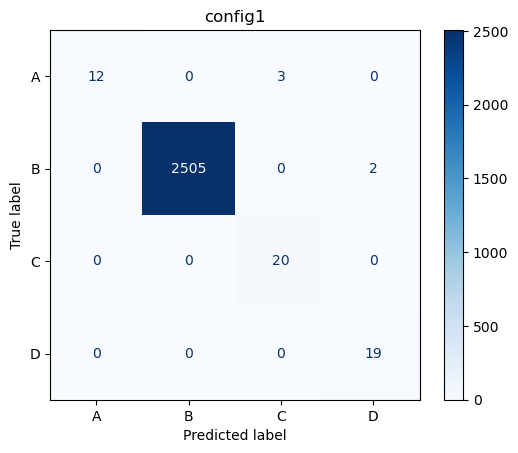


Confusion matrix — config2
    A   B   C     D
A  10   0   0     0
B   0  21   0     0
C   7   0  14     0
D   0   1   8  2949


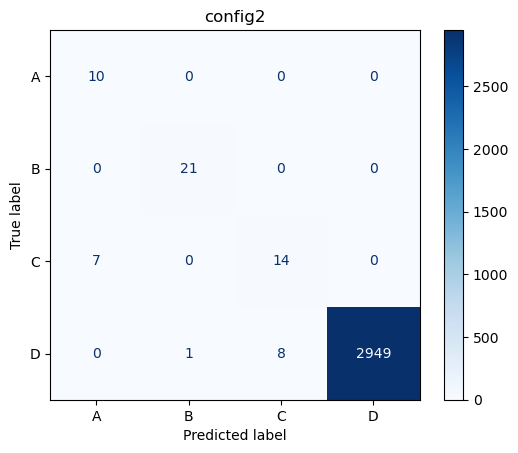


Confusion matrix — config3
      A  B  C   D
A  3495  0  0   0
B     0  7  0   4
C     3  0  9   4
D     0  0  0  15


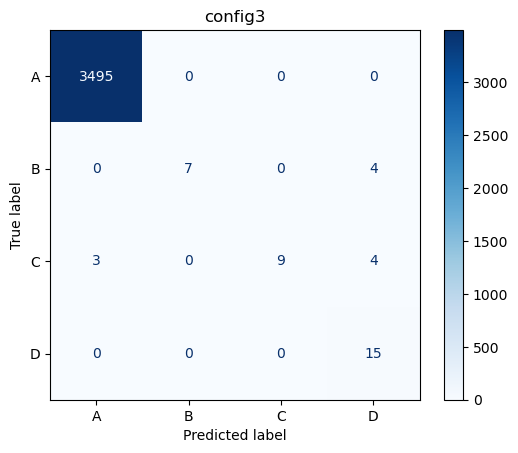


Confusion matrix — config4
    A  B  C     D
A  16  0  0     6
B  15  0  0     0
C  15  0  0     0
D   0  0  0  2884


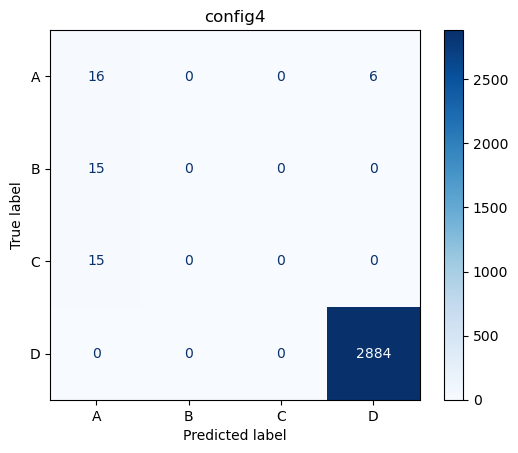


Confusion matrix — config5
    A   B  C     D
A  10   5  0     0
B   0  17  0     0
C   0  20  0     0
D   0   1  0  3031


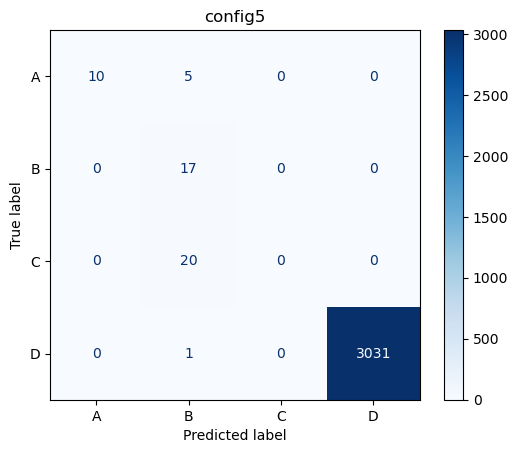


Confusion matrix — config6
      A  B   C  D
A  2929  0  30  0
B     0  6   9  0
C     0  0  14  0
D    19  0   0  3


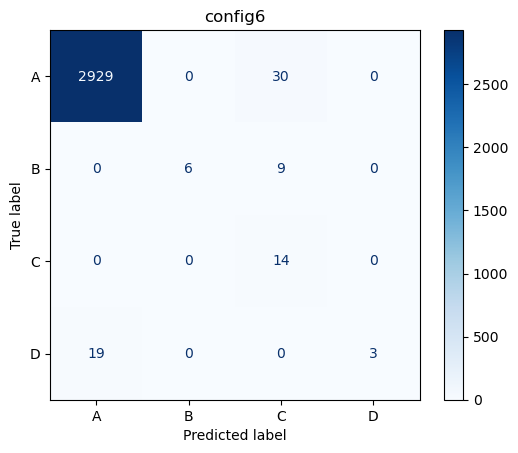


Overall confusion matrix
      A     B   C     D
A  6472     5  33     6
B    15  2556   9     6
C    25    20  57     4
D    19     2   8  8901


In [6]:
# %% [code]  ━━━ Confusion matrix per scene ━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.pyplot as plt  
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1) add TRUE label column ("A"…"D")
label_map = {v: k for k, v in TRUTH_POINTS.items()}  # (x,y)->"A"
def label_from_xy(xy):
    # xy is (x_px, y_px)
    return label_map[tuple(xy)]

data["true_label"] = data[["gt_x", "gt_y"]].apply(
    lambda s: label_from_xy(s.values), axis=1
)

# helper: snap predicted coordinate to nearest A/B/C/D
TP_XY = np.array(list(TRUTH_POINTS.values()))  # (4,2) in px
TP_LABELS = np.array(list(TRUTH_POINTS))

def nearest_label(pred_cm):
    pred_px = np.array(pred_cm) * PX_PER_CM
    dists = np.linalg.norm(TP_XY - pred_px, axis=1)
    return TP_LABELS[dists.argmin()]

# 2) loop scenes and compute confusion
for esc, grp in data.groupby("esc"):
    X_esc = grp[[f"rssi_{aid}" for aid in ANCHOR_IDS]].values
    y_true = grp["true_label"].values

    # reuse global scaler + knn fitted earlier
    y_pred_cm = knn.predict(scaler.transform(X_esc))
    y_pred_lbl = np.array([nearest_label(p) for p in y_pred_cm])

    cm = confusion_matrix(y_true, y_pred_lbl, labels=TP_LABELS)
    print(f"\nConfusion matrix — {esc}")
    print(pd.DataFrame(cm, index=TP_LABELS, columns=TP_LABELS))

    # optional pretty plot
    disp = ConfusionMatrixDisplay(cm, display_labels=TP_LABELS)
    disp.plot(cmap="Blues"); plt.title(esc); plt.show()

# 3) overall confusion matrix
y_all_true = data["true_label"].values
y_all_pred = np.array([
    nearest_label(p) for p in knn.predict(scaler.transform(X))
])
cm_all = confusion_matrix(y_all_true, y_all_pred, labels=TP_LABELS)
print("\nOverall confusion matrix")
print(pd.DataFrame(cm_all, index=TP_LABELS, columns=TP_LABELS))


In [7]:
# %%  Conteo por escena y etiqueta
tabla = (data.groupby(["esc", "true_label"])
               .size()
               .unstack(fill_value=0)
               .sort_index())
print("Muestras por escena y GT:")
display(tabla)

Muestras por escena y GT:


true_label,A,B,C,D
esc,,,,
config1,15,2507,20,19
config2,10,21,21,2958
config3,3495,11,16,15
config4,22,15,15,2884
config5,15,17,20,3032
config6,2959,15,14,22


In [15]:
import pandas as pd
import datetime as dt
from typing import List, Tuple, Dict

def build_gt_dataframe_utc(
        gt_schedules: Dict[str, List[Tuple[str, str, str]]],
        day: str = "2025-07-13"
    ) -> pd.DataFrame:
    """
    Convierte GT_SCHEDULES → DataFrame con columnas:
        scene | timestamp | zone
    timestamp = Unix seconds, zona UTC (GMT 0)
    """
    base_date = dt.date.fromisoformat(day)           # 2025-07-13
    rows = []

    for scene, schedule in gt_schedules.items():
        for start, end, label in schedule:
            # admite "1:02" o "01:02"
            h0, m0 = map(int, start.split(":"))
            h1, m1 = map(int, end.split(":"))

            dt0 = dt.datetime.combine(base_date, dt.time(h0, m0), tzinfo=dt.timezone.utc)
            dt1 = dt.datetime.combine(base_date, dt.time(h1, m1), tzinfo=dt.timezone.utc)

            # rango cerrado [dt0, dt1] con paso 1 s
            rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")

            ts_vals = rng.view("int64") // 1_000_000_000   # a segundos Unix (int)

            rows.append(pd.DataFrame({
                "scene": scene,
                "timestamp": ts_vals,
                "zone": label
            }))

    return pd.concat(rows, ignore_index=True)


df_gt = build_gt_dataframe_utc(GT_SCHEDULES, day="2025-07-13")
print(df_gt.head())

print("\nConteo por escena y zona:")
print(df_gt.groupby(["scene", "zone"]).size().unstack(fill_value=0))



     scene   timestamp zone
0  config1  1752368520    D
1  config1  1752368521    D
2  config1  1752368522    D
3  config1  1752368523    D
4  config1  1752368524    D

Conteo por escena y zona:
zone        A     B     C     D
scene                          
config1   841   541  1141  1081
config2   541  1201  1201   481
config3  1081   601   901   841
config4  1261   841   841   481
config5   841   961  1141   481
config6   541   841   781  1261


C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3874410809.py:27: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")
C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3874410809.py:27: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")
C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3874410809.py:27: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")
C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3874410809.py:27: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")
C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3874410809.py:27: FutureWarning: 'S' is deprecated and will be removed in

C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3746266835.py:51: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")
C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3746266835.py:51: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")
C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3746266835.py:51: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")
C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3746266835.py:51: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range(dt0, dt1, freq="S", tz="UTC")
C:\Users\miguel\AppData\Local\Temp\ipykernel_15936\3746266835.py:51: FutureWarning: 'S' is deprecated and will be removed in

MAE GLOBAL = 0.00 cm

── Leave-One-Out por config ─────────
config1: MAE 0.00 cm
     A    B     C     D
A  841    0     0     0
B    0  541     0     0
C    0    0  1141     0
D    0    0     0  1059


C:\Users\miguel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


config2: MAE 0.00 cm
     A     B     C    D
A  541     0     0    0
B    0  1172     0    0
C    0     0  1201    0
D    0     0     0  481


C:\Users\miguel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


...

config4: MAE 0.00 cm
      A    B    C    D
A  1212    0    0    0
B     0  841    0    0
C     0    0  841    0
D     0    0    0  481


C:\Users\miguel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


config5: MAE 0.00 cm
     A    B     C    D
A  841    0     0    0
B    0  947     0    0
C    0    0  1141    0
D    0    0     0  481


C:\Users\miguel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


config6: MAE 0.06 cm
     A    B    C     D
A  540    1    0     0
B    0  841    0     0
C    0    0  781     0
D    0    0    0  1261
